Number of Rows:428
Number of Columns:17


Statistics of The Numerical Data:       EngineSize   Cylinders  Horsepower    MPG_City  MPG_Highway  \
count  428.000000  426.000000  428.000000  428.000000   428.000000   
mean     3.196729    5.807512  215.885514   20.060748    26.843458   
std      1.108595    1.558443   71.836032    5.238218     5.741201   
min      1.300000    3.000000   73.000000   10.000000    12.000000   
25%      2.375000    4.000000  165.000000   17.000000    24.000000   
50%      3.000000    6.000000  210.000000   19.000000    26.000000   
75%      3.900000    6.000000  255.000000   21.250000    29.000000   
max      8.300000   12.000000  500.000000   60.000000    66.000000   

            Weight   Wheelbase      Length  Unnamed: 15  Unnamed: 16  
count   428.000000  428.000000  428.000000          0.0          0.0  
mean   3577.953271  108.154206  186.362150          NaN          NaN  
std     758.983215    8.311813   14.357991          NaN          NaN  
min    185

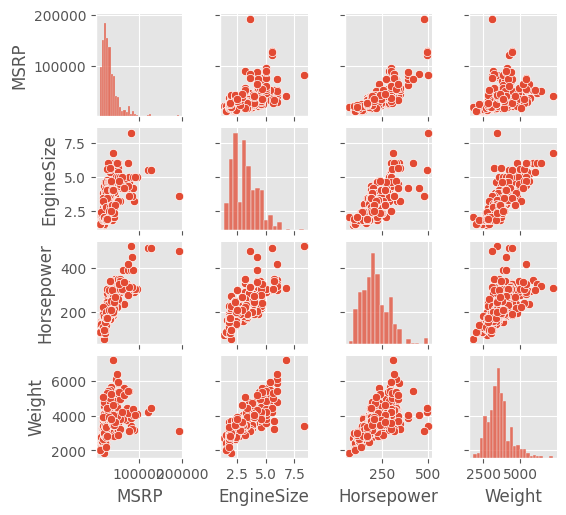

Correlation of an DataSet:                   MSRP  EngineSize  Horsepower    Weight  Type_SUV  \
MSRP           1.000000    0.572803    0.826521  0.443136  0.035699   
EngineSize     0.572803    1.000000    0.793250  0.808707  0.262413   
Horsepower     0.826521    0.793250    1.000000  0.631758  0.112270   
Weight         0.443136    0.808707    0.631758  1.000000  0.460892   
Type_SUV       0.035699    0.262413    0.112270  0.460892  1.000000   
Type_Sedan    -0.193945   -0.269069   -0.249979 -0.302106 -0.511757   
Type_Sports    0.393911    0.104924    0.348310 -0.127104 -0.142582   
Type_Truck    -0.098151    0.193643    0.030431  0.215783 -0.098930   
Type_Wagon    -0.055428   -0.108784   -0.083744 -0.051378 -0.111442   
Origin_Europe  0.505276    0.000503    0.319127  0.084156 -0.109060   
Origin_USA    -0.163445    0.287932   -0.030837  0.181212  0.060978   

               Type_Sedan  Type_Sports  Type_Truck  Type_Wagon  Origin_Europe  \
MSRP            -0.193945     0.393911  

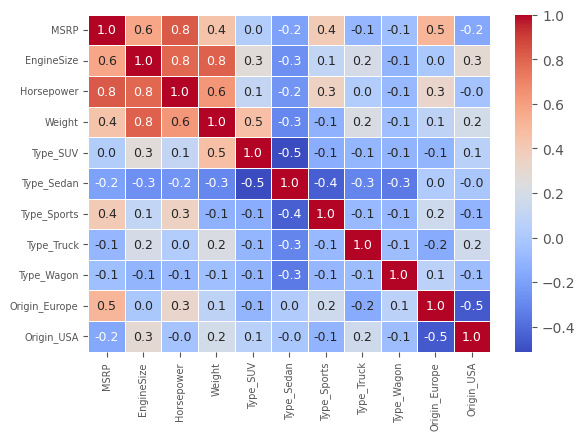



The Final Columns of The DataSet After Correlation:        MSRP  EngineSize  Horsepower  Weight  Type_Sedan  Type_Sports  \
0    36945.0         3.5         265    4451       False        False   
1    23820.0         2.0         200    2778        True        False   
2    26990.0         2.4         200    3230        True        False   
3    33195.0         3.2         270    3575        True        False   
4    43755.0         3.5         225    3880        True        False   
..       ...         ...         ...     ...         ...          ...   
423  40565.0         2.4         197    3450        True        False   
424  42565.0         2.3         242    3450        True        False   
425  45210.0         2.9         268    3653        True        False   
426  26135.0         1.9         170    2822       False        False   
427  35145.0         2.5         208    3823       False        False   

     Type_Wagon  Origin_Europe  Origin_USA  
0         False          

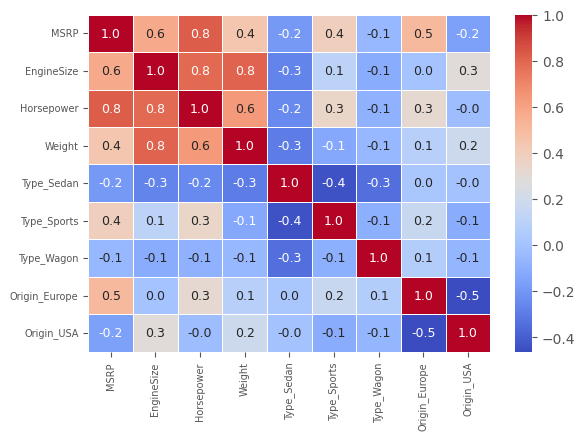



Training The DataSet of X:
     EngineSize  Horsepower  Weight  Type_Sedan  Type_Sports  Type_Wagon  \
257         3.2         215    3430        True        False       False   
315         3.5         245    3801       False        False        True   
229         5.4         300    5969       False        False       False   
5           3.5         225    3893        True        False       False   
427         2.5         208    3823       False        False        True   
..          ...         ...     ...         ...          ...         ...   
325         4.6         275    3790        True        False       False   
192         4.2         294    3874        True        False       False   
117         3.7         215    4542       False        False       False   
47          3.4         185    4024       False        False       False   
172         2.0         138    2635        True        False       False   

     Origin_Europe  Origin_USA  
257           True       

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pk
import os
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from PLT import Image

# ─────────────────────────────────────────────
#  PAGE CONFIG
# ─────────────────────────────────────────────
st.set_page_config(
    page_title="CarPrice AI",
    page_icon="🚗",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ─────────────────────────────────────────────
#  CUSTOM CSS  – Sleek dark automotive theme
# ─────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Rajdhani:wght@400;500;600;700&family=Inter:wght@300;400;500&display=swap');

/* ── Root variables ── */
:root {
    --red:    #E63946;
    --gold:   #FFD166;
    --dark:   #0A0A0F;
    --card:   #111118;
    --border: #1E1E2A;
    --muted:  #4A4A6A;
    --light:  #E8E8F0;
}

/* ── Global ── */
html, body, [class*="css"] {
    font-family: 'Inter', sans-serif;
    background-color: var(--dark);
    color: var(--light);
}
.stApp { background-color: var(--dark); }
.block-container { padding: 2rem 3rem 4rem; }

/* ── Sidebar ── */
[data-testid="stSidebar"] {
    background: #0D0D14;
    border-right: 1px solid var(--border);
}
[data-testid="stSidebar"] .stSelectbox label,
[data-testid="stSidebar"] .stNumberInput label,
[data-testid="stSidebar"] .stRadio label,
[data-testid="stSidebar"] p {
    color: #AAAACC !important;
    font-size: 0.82rem;
    letter-spacing: 0.05em;
    text-transform: uppercase;
}

/* ── Hero banner ── */
.hero {
    background: linear-gradient(135deg, #0D0D14 0%, #1A0A18 50%, #0A0F1A 100%);
    border: 1px solid var(--border);
    border-radius: 16px;
    padding: 2.5rem 3rem;
    margin-bottom: 2rem;
    position: relative;
    overflow: hidden;
}
.hero::before {
    content: "";
    position: absolute;
    top: -80px; right: -80px;
    width: 300px; height: 300px;
    background: radial-gradient(circle, rgba(230,57,70,0.15) 0%, transparent 70%);
    border-radius: 50%;
}
.hero::after {
    content: "";
    position: absolute;
    bottom: -60px; left: 30%;
    width: 200px; height: 200px;
    background: radial-gradient(circle, rgba(255,209,102,0.08) 0%, transparent 70%);
    border-radius: 50%;
}
.hero-title {
    font-family: 'Rajdhani', sans-serif;
    font-size: 3.2rem;
    font-weight: 700;
    letter-spacing: 0.08em;
    color: #FFFFFF;
    margin: 0;
    line-height: 1;
}
.hero-title span { color: var(--red); }
.hero-sub {
    font-size: 0.9rem;
    color: var(--muted);
    margin-top: 0.5rem;
    letter-spacing: 0.12em;
    text-transform: uppercase;
}
.hero-badge {
    display: inline-block;
    background: rgba(230,57,70,0.12);
    border: 1px solid rgba(230,57,70,0.4);
    border-radius: 20px;
    padding: 0.25rem 0.9rem;
    font-size: 0.72rem;
    color: var(--red);
    letter-spacing: 0.15em;
    text-transform: uppercase;
    margin-bottom: 1rem;
}

/* ── Metric cards ── */
.metric-row { display: flex; gap: 1rem; margin-bottom: 2rem; }
.metric-card {
    flex: 1;
    background: var(--card);
    border: 1px solid var(--border);
    border-radius: 12px;
    padding: 1.4rem 1.6rem;
    position: relative;
    overflow: hidden;
    transition: border-color 0.2s;
}
.metric-card:hover { border-color: var(--red); }
.metric-card::before {
    content: "";
    position: absolute;
    top: 0; left: 0; right: 0;
    height: 2px;
    background: linear-gradient(90deg, var(--red), transparent);
}
.metric-label {
    font-size: 0.68rem;
    color: var(--muted);
    text-transform: uppercase;
    letter-spacing: 0.12em;
    margin-bottom: 0.4rem;
}
.metric-value {
    font-family: 'Rajdhani', sans-serif;
    font-size: 2rem;
    font-weight: 700;
    color: var(--light);
    line-height: 1;
}
.metric-delta {
    font-size: 0.72rem;
    color: #4ECB71;
    margin-top: 0.3rem;
}

/* ── Section headers ── */
.section-header {
    font-family: 'Rajdhani', sans-serif;
    font-size: 1.1rem;
    font-weight: 600;
    color: var(--light);
    letter-spacing: 0.1em;
    text-transform: uppercase;
    border-left: 3px solid var(--red);
    padding-left: 0.75rem;
    margin: 1.5rem 0 1rem;
}

/* ── Prediction result box ── */
.pred-box {
    background: linear-gradient(135deg, #14080C 0%, #0C0C18 100%);
    border: 1px solid rgba(230,57,70,0.5);
    border-radius: 16px;
    padding: 2.5rem;
    text-align: center;
    margin: 1.5rem 0;
    box-shadow: 0 0 40px rgba(230,57,70,0.08);
}
.pred-label {
    font-size: 0.75rem;
    text-transform: uppercase;
    letter-spacing: 0.2em;
    color: var(--muted);
    margin-bottom: 0.5rem;
}
.pred-value {
    font-family: 'Rajdhani', sans-serif;
    font-size: 3.8rem;
    font-weight: 700;
    color: var(--red);
    line-height: 1;
}
.pred-model {
    font-size: 0.72rem;
    color: var(--muted);
    margin-top: 0.5rem;
}
.pred-compare {
    display: flex;
    justify-content: center;
    gap: 2rem;
    margin-top: 1.5rem;
    padding-top: 1.5rem;
    border-top: 1px solid var(--border);
}
.pred-compare-item { text-align: center; }
.pred-compare-label {
    font-size: 0.65rem;
    color: var(--muted);
    text-transform: uppercase;
    letter-spacing: 0.1em;
}
.pred-compare-val {
    font-family: 'Rajdhani', sans-serif;
    font-size: 1.5rem;
    font-weight: 600;
    color: var(--gold);
}

/* ── Streamlit widget overrides ── */
.stSlider > div > div { background: var(--border) !important; }
.stSlider > div > div > div > div { background: var(--red) !important; }
.stSelectbox > div > div {
    background: var(--card) !important;
    border-color: var(--border) !important;
    color: var(--light) !important;
    border-radius: 8px !important;
}
.stNumberInput > div > div > input {
    background: var(--card) !important;
    border-color: var(--border) !important;
    color: var(--light) !important;
    border-radius: 8px !important;
}
.stButton > button {
    width: 100%;
    background: linear-gradient(135deg, var(--red), #B02030) !important;
    color: white !important;
    border: none !important;
    border-radius: 10px !important;
    font-family: 'Rajdhani', sans-serif !important;
    font-size: 1.1rem !important;
    font-weight: 700 !important;
    letter-spacing: 0.12em !important;
    text-transform: uppercase !important;
    padding: 0.85rem !important;
    cursor: pointer !important;
    box-shadow: 0 4px 20px rgba(230,57,70,0.3) !important;
    transition: all 0.2s !important;
}
.stButton > button:hover {
    box-shadow: 0 6px 28px rgba(230,57,70,0.5) !important;
    transform: translateY(-1px) !important;
}

/* ── Tabs ── */
.stTabs [data-baseweb="tab-list"] {
    background: var(--card);
    border-radius: 12px 12px 0 0;
    border: 1px solid var(--border);
    border-bottom: none;
    gap: 0;
}
.stTabs [data-baseweb="tab"] {
    font-family: 'Rajdhani', sans-serif;
    font-weight: 600;
    letter-spacing: 0.08em;
    text-transform: uppercase;
    font-size: 0.85rem;
    color: var(--muted) !important;
    padding: 0.8rem 1.5rem;
    border: none;
}
.stTabs [aria-selected="true"] {
    color: var(--red) !important;
    background: transparent;
    border-bottom: 2px solid var(--red) !important;
}
.stTabs [data-baseweb="tab-panel"] {
    background: var(--card);
    border: 1px solid var(--border);
    border-top: none;
    border-radius: 0 0 12px 12px;
    padding: 1.5rem;
}

/* ── Info / warning boxes ── */
.info-pill {
    display: inline-flex;
    align-items: center;
    gap: 0.4rem;
    background: rgba(255,209,102,0.08);
    border: 1px solid rgba(255,209,102,0.25);
    border-radius: 6px;
    padding: 0.4rem 0.9rem;
    font-size: 0.78rem;
    color: var(--gold);
}

/* ── Divider ── */
hr { border-color: var(--border) !important; }

/* ── Hide Streamlit chrome ── */
#MainMenu, footer, header { visibility: hidden; }
</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────────
#  LOAD + TRAIN MODEL (cached)
# ─────────────────────────────────────────────
@st.cache_resource
def load_and_train(csv_path: str):
    df = pd.read_csv(csv_path)
    drop = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")
    df_clean = drop.dropna().copy()
    df_clean["MSRP"] = (
        df_clean["MSRP"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )
    col_keep = ["MSRP", "Type", "Origin", "EngineSize", "Horsepower", "Weight"]
    df_col = df_clean[col_keep]
    df_final = pd.get_dummies(df_col, columns=["Type", "Origin"], drop_first=True)
    if "Type_SUV" in df_final.columns:
        df_final = df_final.drop(["Type_SUV"], axis=1, errors="ignore")
    if "Type_Truck" in df_final.columns:
        df_final = df_final.drop(["Type_Truck"], axis=1, errors="ignore")

    features = ["EngineSize", "Horsepower", "Weight", "Type_Sedan", "Type_Sports",
                "Type_Wagon", "Origin_Europe", "Origin_USA"]
    features = [f for f in features if f in df_final.columns]

    df_train, df_test = train_test_split(df_final, train_size=0.80, random_state=0)
    X_train = df_train[features]; y_train = df_train["MSRP"].astype("int")
    X_test  = df_test[features];  y_test  = df_test["MSRP"].astype("int")

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train)
    X_te_s = scaler.transform(X_test)

    lr = LinearRegression()
    lr.fit(X_tr_s, y_train)

    poly = PolynomialFeatures(degree=2)
    x_poly = poly.fit_transform(X_tr_s)
    pr = LinearRegression()
    pr.fit(x_poly, y_train)

    scores = {
        "lr_train": lr.score(X_tr_s, y_train) * 100,
        "lr_test":  lr.score(X_te_s, y_test)  * 100,
        "pr_train": pr.score(x_poly, y_train) * 100,
        "pr_test":  pr.score(poly.transform(X_te_s), y_test) * 100,
    }
    return lr, pr, scaler, poly, df_final, features, scores, df_clean


# ─────────────────────────────────────────────
#  SIDEBAR – file upload + inputs
# ─────────────────────────────────────────────
with st.sidebar:
    st.markdown("""
    <div style='padding:1rem 0 0.5rem;'>
        <div style='font-family:Rajdhani,sans-serif;font-size:1.4rem;font-weight:700;
                    color:#E8E8F0;letter-spacing:0.1em;'>CAR<span style='color:#E63946;'>PRICE</span></div>
        <div style='font-size:0.65rem;color:#4A4A6A;letter-spacing:0.15em;
                    text-transform:uppercase;margin-top:0.2rem;'>AI Prediction Engine</div>
    </div>
    """, unsafe_allow_html=True)
    st.markdown("---")

    st.markdown("##### 📂 Dataset")
    uploaded = st.file_uploader("Upload Cars Data CSV", type=["csv"])
    csv_path = None
    if uploaded:
        tmp = "/tmp/cars_uploaded.csv"
        with open(tmp, "wb") as f:
            f.write(uploaded.getbuffer())
        csv_path = tmp
    elif os.path.exists("Cars Data.csv"):
        csv_path = "Cars Data.csv"

    if not csv_path:
        st.warning("⚠️ Upload your **Cars Data.csv** to begin.")
        st.stop()

    st.markdown("---")
    st.markdown("##### ⚙️ Car Specifications")

    engine_size  = st.slider("Engine Size (L)",    1.0, 8.0, 3.0, 0.1)
    horsepower   = st.slider("Horsepower (HP)",    50,  500, 200, 5)
    weight       = st.slider("Weight (lbs)",       1500, 6000, 3200, 50)

    st.markdown("##### 🏷️ Car Type")
    car_type = st.radio("", ["SUV / Truck", "Sedan", "Sports", "Wagon"], horizontal=False)
    type_sedan  = 1 if car_type == "Sedan"  else 0
    type_sports = 1 if car_type == "Sports" else 0
    type_wagon  = 1 if car_type == "Wagon"  else 0

    st.markdown("##### 🌍 Origin")
    origin = st.radio("", ["Asia", "Europe", "USA"], horizontal=True)
    origin_europe = 1 if origin == "Europe" else 0
    origin_usa    = 1 if origin == "USA"    else 0

    st.markdown("---")
    predict_btn = st.button("🔍 PREDICT PRICE")

# ─────────────────────────────────────────────
#  LOAD MODEL
# ─────────────────────────────────────────────
with st.spinner("Loading model…"):
    lr, pr, scaler, poly, df_final, features, scores, df_clean = load_and_train(csv_path)

# ─────────────────────────────────────────────
#  HERO BANNER
# ─────────────────────────────────────────────
st.markdown("""
<div class="hero">
    <div class="hero-badge">🚗 Machine Learning · Regression Analysis</div>
    <div class="hero-title">Car<span>Price</span> AI</div>
    <div class="hero-sub">Predict vehicle market value with Linear &amp; Polynomial Regression</div>
</div>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────────
#  TOP METRIC ROW
# ─────────────────────────────────────────────
col1, col2, col3, col4 = st.columns(4)
metrics = [
    ("Dataset Rows",       f"{df_clean.shape[0]:,}",        "Cars analysed"),
    ("LR Train Score",     f"{scores['lr_train']:.1f}%",    "Linear Regression"),
    ("LR Test Score",      f"{scores['lr_test']:.1f}%",     "Linear Regression"),
    ("Poly Test Score",    f"{scores['pr_test']:.1f}%",     "Polynomial (deg 2)"),
]
for col, (label, value, sub) in zip([col1, col2, col3, col4], metrics):
    with col:
        st.markdown(f"""
        <div class="metric-card">
            <div class="metric-label">{label}</div>
            <div class="metric-value">{value}</div>
            <div class="metric-delta">{sub}</div>
        </div>""", unsafe_allow_html=True)

# ─────────────────────────────────────────────
#  PREDICTION LOGIC
# ─────────────────────────────────────────────
def make_prediction():
    row = {
        "EngineSize":    [engine_size],
        "Horsepower":    [horsepower],
        "Weight":        [weight],
        "Type_Sedan":    [type_sedan],
        "Type_Sports":   [type_sports],
        "Type_Wagon":    [type_wagon],
        "Origin_Europe": [origin_europe],
        "Origin_USA":    [origin_usa],
    }
    df_row  = pd.DataFrame({k: v for k, v in row.items() if k in features})
    scaled  = scaler.transform(df_row)
    lr_pred = lr.predict(scaled)[0]
    pr_pred = pr.predict(poly.transform(scaled))[0]
    return lr_pred, pr_pred

# ─────────────────────────────────────────────
#  TABS
# ─────────────────────────────────────────────
tab1, tab2, tab3 = st.tabs(["🎯  Prediction", "📊  Analytics", "🔥  Correlation"])

# ── TAB 1: PREDICTION ──────────────────────
with tab1:
    if predict_btn:
        lr_pred, pr_pred = make_prediction()
        avg = (lr_pred + pr_pred) / 2

        st.markdown(f"""
        <div class="pred-box">
            <div class="pred-label">Estimated Market Price</div>
            <div class="pred-value">${avg:,.0f}</div>
            <div class="pred-model">Ensemble Average · Linear + Polynomial</div>
            <div class="pred-compare">
                <div class="pred-compare-item">
                    <div class="pred-compare-label">Linear Regression</div>
                    <div class="pred-compare-val">${lr_pred:,.0f}</div>
                </div>
                <div class="pred-compare-item">
                    <div class="pred-compare-label">Polynomial (deg 2)</div>
                    <div class="pred-compare-val">${pr_pred:,.0f}</div>
                </div>
            </div>
        </div>
        """, unsafe_allow_html=True)

        # input summary
        st.markdown('<div class="section-header">Input Summary</div>', unsafe_allow_html=True)
        c1, c2, c3 = st.columns(3)
        with c1:
            st.metric("Engine Size", f"{engine_size} L")
            st.metric("Car Type", car_type)
        with c2:
            st.metric("Horsepower", f"{horsepower} HP")
            st.metric("Origin", origin)
        with c3:
            st.metric("Weight", f"{weight:,} lbs")

    else:
        st.markdown("""
        <div style="text-align:center;padding:4rem 2rem;color:#4A4A6A;">
            <div style="font-size:3rem;margin-bottom:1rem;">🚘</div>
            <div style="font-family:Rajdhani,sans-serif;font-size:1.3rem;
                        letter-spacing:0.1em;text-transform:uppercase;">
                Configure your car in the sidebar<br>and hit <span style="color:#E63946;">Predict Price</span>
            </div>
        </div>
        """, unsafe_allow_html=True)

# ── TAB 2: ANALYTICS ───────────────────────
with tab2:
    st.markdown('<div class="section-header">Price Distribution</div>', unsafe_allow_html=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="#111118")
    for ax in axes:
        ax.set_facecolor("#111118")
        for spine in ax.spines.values():
            spine.set_edgecolor("#1E1E2A")

    axes[0].hist(df_clean["MSRP"].astype(float), bins=40,
                 color="#E63946", alpha=0.8, edgecolor="#0A0A0F")
    axes[0].set_title("MSRP Distribution", color="#E8E8F0", fontsize=11, pad=10)
    axes[0].set_xlabel("Price ($)", color="#4A4A6A", fontsize=9)
    axes[0].set_ylabel("Count", color="#4A4A6A", fontsize=9)
    axes[0].tick_params(colors="#4A4A6A", labelsize=8)

    if "Type" in df_clean.columns:
        type_avg = df_clean.groupby("Type")["MSRP"].mean().sort_values(ascending=False)
        bars = axes[1].bar(type_avg.index, type_avg.values,
                           color=["#E63946", "#FFD166", "#4ECB71", "#6CA0DC", "#9B7FE8"])
        axes[1].set_title("Avg Price by Type", color="#E8E8F0", fontsize=11, pad=10)
        axes[1].set_xlabel("Type", color="#4A4A6A", fontsize=9)
        axes[1].set_ylabel("Avg MSRP ($)", color="#4A4A6A", fontsize=9)
        axes[1].tick_params(colors="#4A4A6A", labelsize=8)

    plt.tight_layout()
    st.pyplot(fig)

    st.markdown('<div class="section-header">Pairplot — Key Numeric Features</div>',
                unsafe_allow_html=True)
    num_cols = ["MSRP", "EngineSize", "Horsepower", "Weight"]
    avail = [c for c in num_cols if c in df_final.columns]
    pair_fig = sns.pairplot(df_final[avail], height=1.8, aspect=1,
                            plot_kws={"alpha": 0.5, "color": "#E63946", "s": 10},
                            diag_kws={"color": "#FFD166", "alpha": 0.7})
    pair_fig.figure.patch.set_facecolor("#111118")
    for ax in pair_fig.axes.flat:
        ax.set_facecolor("#111118")
        ax.tick_params(colors="#4A4A6A", labelsize=7)
        ax.xaxis.label.set_color("#4A4A6A")
        ax.yaxis.label.set_color("#4A4A6A")
        for spine in ax.spines.values():
            spine.set_edgecolor("#1E1E2A")
    st.pyplot(pair_fig.figure)

# ── TAB 3: CORRELATION ─────────────────────
with tab3:
    st.markdown('<div class="section-header">Full Correlation Heatmap</div>',
                unsafe_allow_html=True)
    corr = df_final.corr()
    fig2, ax2 = plt.subplots(figsize=(11, 7), facecolor="#111118")
    ax2.set_facecolor("#111118")
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f",
        cmap=sns.diverging_palette(10, 220, as_cmap=True),
        linewidths=0.5, linecolor="#1E1E2A",
        annot_kws={"size": 8, "color": "#E8E8F0"},
        ax=ax2, cbar_kws={"shrink": 0.8}
    )
    ax2.tick_params(colors="#AAAACC", labelsize=8)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha="right")
    plt.title("Feature Correlation Matrix", color="#E8E8F0", pad=14, fontsize=12)
    plt.tight_layout()
    st.pyplot(fig2)

    st.markdown('<div class="section-header">MSRP Correlation Ranking</div>',
                unsafe_allow_html=True)
    if "MSRP" in corr.columns:
        msrp_corr = corr["MSRP"].drop("MSRP").sort_values(key=abs, ascending=False)
        fig3, ax3 = plt.subplots(figsize=(8, 4), facecolor="#111118")
        ax3.set_facecolor("#111118")
        colors = ["#E63946" if v > 0 else "#6CA0DC" for v in msrp_corr.values]
        ax3.barh(msrp_corr.index, msrp_corr.values, color=colors, alpha=0.85)
        ax3.axvline(0, color="#4A4A6A", linewidth=0.8)
        ax3.tick_params(colors="#AAAACC", labelsize=8)
        ax3.set_xlabel("Correlation with MSRP", color="#4A4A6A", fontsize=9)
        ax3.set_title("Feature Impact on Price", color="#E8E8F0", fontsize=11, pad=10)
        for spine in ax3.spines.values():
            spine.set_edgecolor("#1E1E2A")
        plt.tight_layout()
        st.pyplot(fig3)

# ─────────────────────────────────────────────
#  FOOTER
# ─────────────────────────────────────────────
st.markdown("---")
st.markdown("""
<div style="text-align:center;color:#2A2A3A;font-size:0.72rem;letter-spacing:0.1em;
            text-transform:uppercase;padding:1rem 0 0.5rem;">
    CarPrice AI · Built with Streamlit · Linear &amp; Polynomial Regression
</div>
""", unsafe_allow_html=True)